In [19]:
import os
import re
import h5py
import numpy as np
from collections import defaultdict
import spikeinterface.extractors as se
from scipy.signal import butter, filtfilt, resample_poly
import neurokit2 as nk

In [20]:
from file_conversion import trodes_ECU_to_h5_clean_raw as trodes

In [21]:
import sys
import os

# Add your script folder to Python's path
sys.path.append(r"C:\Users\sjs93\OneDrive\Documents\respiratory_pilot\src\file_conversion")

# Import your conversion function
import trodes_ECU_to_h5_clean_raw as trodes

In [22]:
import trodes_ECU_to_h5_clean_raw as trodes

print("Loaded from:", trodes.__file__)
print("Functions:", dir(trodes))

Loaded from: C:\Users\sjs93\OneDrive\Documents\respiratory_pilot\src\file_conversion\trodes_ECU_to_h5_clean_raw.py
Functions: ['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'butter', 'convert_all_rec_to_h5', 'convert_sessions', 'filtfilt', 'h5py', 'load_trodes_exports', 'nk', 'np', 'os', 'parse_fields', 'read_trodes_dat_file', 'resample_poly', 'write_h5']


In [23]:
dir(trodes)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'butter',
 'convert_all_rec_to_h5',
 'convert_sessions',
 'filtfilt',
 'h5py',
 'load_trodes_exports',
 'nk',
 'np',
 'os',
 'parse_fields',
 'read_trodes_dat_file',
 'resample_poly',
 'write_h5']

In [24]:
session_dir = r"D:\BLA_ChR_resp\BLA_resp_ChR_cm_hc\2_2_s_cm_2_1_d_20260108_120453.rec"

In [25]:
with open(r"C:\Users\sjs93\OneDrive\Documents\respiratory_pilot\src\file_conversion\trodes_ECU_to_h5_clean_raw.py", "r") as f:
    for i in range(30):
        print(f.readline())

import os

import h5py

import numpy as np

from scipy.signal import butter, filtfilt, resample_poly

import neurokit2 as nk



# ============================================================

# Trodes binary reader (NumPy-safe)

# ============================================================



def parse_fields(field_str):

    import re



    components = re.split(r"\s+", re.sub(r"[<>]", " ", field_str).strip())

    dtype_spec = []



    i = 0

    while i < len(components):

        name = components[i]

        type_str = components[i + 1]

        count = 1



        if "*" in type_str:

            n, t = type_str.split("*")

            if n.isdigit():

                count = int(n)

                type_str = t

            else:

                count = int(t)

                type_str = n



In [26]:
analog, dio, time = trodes.load_trodes_exports(session_dir)

In [27]:
print("Analog:", analog.keys())
print("DIO:", dio.keys())
print("Time:", time.keys())

Analog: dict_keys(['2_2_s_cm_2_1_d_20260108_120453.analog_ECU_Ain1', '2_2_s_cm_2_1_d_20260108_120453.timestamps'])
DIO: dict_keys([])
Time: dict_keys(['2_2_s_cm_2_1_d_20260108_120453.timestamps'])


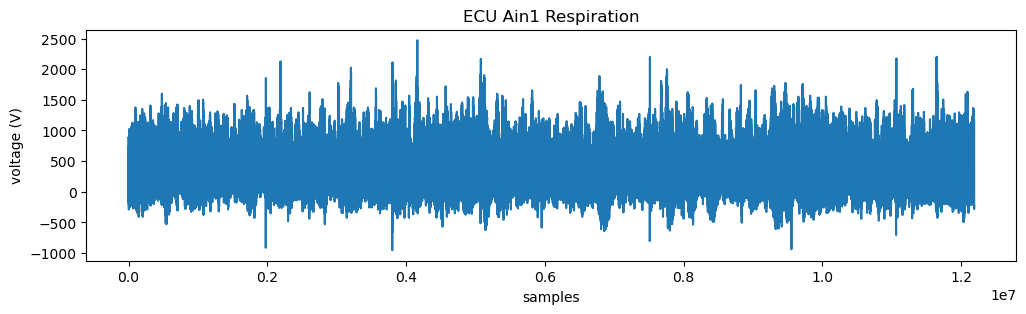

In [28]:
import matplotlib.pyplot as plt

analog_key = [k for k in analog if "Ain1" in k][0]
resp = analog[analog_key]["data"]["voltage"]

plt.figure(figsize=(12, 3))
plt.plot(resp)
plt.title("ECU Ain1 Respiration")
plt.xlabel("samples")
plt.ylabel("voltage (V)")
plt.show()


In [ ]:
time_key = list(time.keys())[0]
time_samples = time[time_key]["data"]

fs = 100  # your ECU sampling rate
time_array = time_samples["time"] / fs

In [ ]:
import os

out_dir = r"D:\BLA_ChR_resp\BLA_resp_ChR_cm_hc\h5_outputs"
os.makedirs(out_dir, exist_ok=True)

out_h5 = os.path.join(
    out_dir,
    "2_2_s_cm_2_1_d_20260108_120453.h5"
)

trodes.write_h5(out_h5, analog, dio, time)

print("Exists:", os.path.exists(out_h5))

  ✓ Saved cleaned respiration
Exists: True


In [32]:
import h5py

f = h5py.File(out_h5, "r")
print(list(f.keys()))
print(f["resp_clean"].keys())

['analog', 'dio', 'resp_clean', 'time']
<KeysViewHDF5 ['signal', 'time']>


In [34]:
data_root = r"D:\BLA_ChR_resp\BLA_resp_ChR_cm_hc"
output_dir = r"D:\BLA_ChR_resp\BLA_resp_ChR_cm_hc\h5_outputs"

trodes.convert_sessions(data_root, output_dir)


Processing: 1_1_d_cm_1_2_i_20260106_134350.rec
  ✓ Saved cleaned respiration
  Wrote D:\BLA_ChR_resp\BLA_resp_ChR_cm_hc\h5_outputs\1_1_d_cm_1_2_i_20260106_134350.h5

Processing: 1_1_i_cm_1_3_s_20260107_163611.rec
  ✓ Saved cleaned respiration
  Wrote D:\BLA_ChR_resp\BLA_resp_ChR_cm_hc\h5_outputs\1_1_i_cm_1_3_s_20260107_163611.h5

Processing: 1_2_d_cm_1_3_s_20260108_114416.rec
  ✓ Saved cleaned respiration
  Wrote D:\BLA_ChR_resp\BLA_resp_ChR_cm_hc\h5_outputs\1_2_d_cm_1_3_s_20260108_114416.h5

Processing: 1_3_s_1_2_d_20260107_165340.rec
  ✓ Saved cleaned respiration
  Wrote D:\BLA_ChR_resp\BLA_resp_ChR_cm_hc\h5_outputs\1_3_s_1_2_d_20260107_165340.h5

Processing: 1_3_s_cm_1_1_i_20260106_122823.rec
  ✓ Saved cleaned respiration
  Wrote D:\BLA_ChR_resp\BLA_resp_ChR_cm_hc\h5_outputs\1_3_s_cm_1_1_i_20260106_122823.h5

Processing: 2_1_d_cm_2.3_i_20260106_105109.rec
  ✓ Saved cleaned respiration
  Wrote D:\BLA_ChR_resp\BLA_resp_ChR_cm_hc\h5_outputs\2_1_d_cm_2.3_i_20260106_105109.h5

Processin

In [48]:
import os

h5_dir = r"D:\BLA_ChR_resp\BLA_resp_ChR_cm_hc\h5_outputs"

h5_files = sorted([
    os.path.join(h5_dir, f)
    for f in os.listdir(h5_dir)
    if f.endswith(".h5")
])

len(h5_files), h5_files[:3]

(24,
 ['D:\\BLA_ChR_resp\\BLA_resp_ChR_cm_hc\\h5_outputs\\1_1_d_cm_1_2_i_20260106_134350.h5',
  'D:\\BLA_ChR_resp\\BLA_resp_ChR_cm_hc\\h5_outputs\\1_1_i_cm_1_3_s_20260107_163611.h5',
  'D:\\BLA_ChR_resp\\BLA_resp_ChR_cm_hc\\h5_outputs\\1_2_d_cm_1_3_s_20260108_114416.h5'])

In [49]:
import h5py

def load_ecu_h5_safe(h5_path):
    try:
        with h5py.File(h5_path, "r") as f:

            analog = {}
            dio = {}
            time = {}

            if "analog" in f:
                for k in f["analog"].keys():
                    analog[k] = f["analog"][k][()]

            if "dio" in f:
                for k in f["dio"].keys():
                    dio[k] = f["dio"][k][()]

            if "time" in f:
                for k in f["time"].keys():
                    time[k] = f["time"][k][()]

        return analog, dio, time

    except Exception as e:
        print(f"❌ Skipping {h5_path}")
        print(e)
        return None, None, None

In [50]:
all_sessions = {}

for h5_path in h5_files:
    session_name = os.path.basename(h5_path).replace(".h5", "")

    analog, dio, time = load_ecu_h5_safe(h5_path)

    if analog is None:
        continue

    all_sessions[session_name] = {
        "analog": analog,
        "dio": dio,
        "time": time
    }

print("Loaded sessions:", len(all_sessions))

Loaded sessions: 24


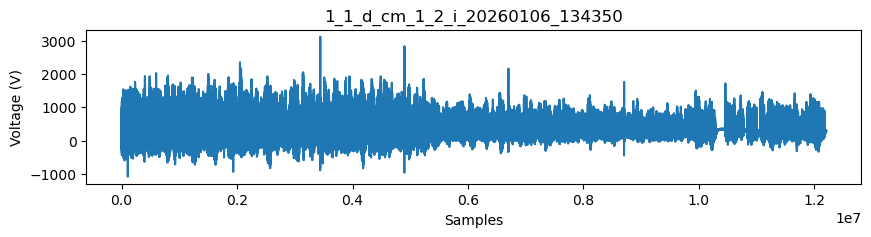

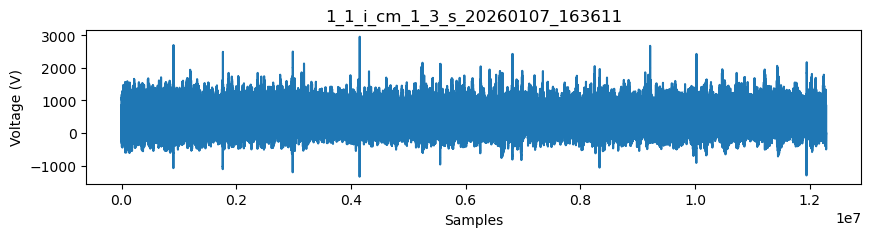

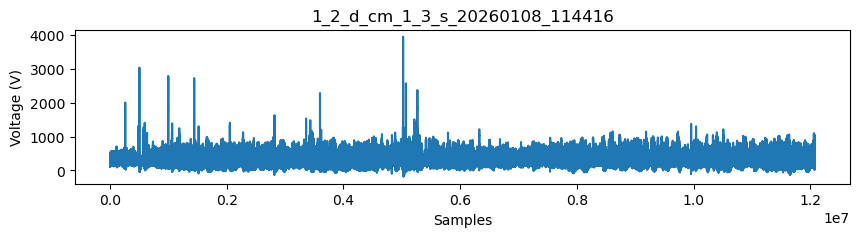

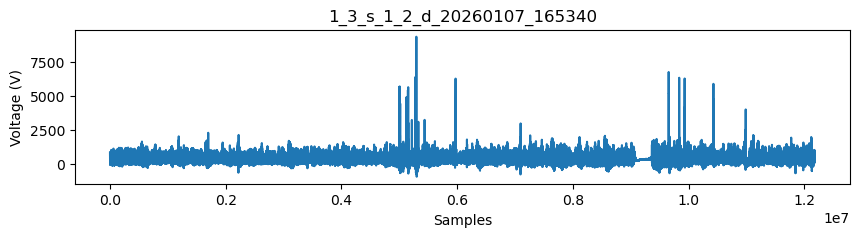

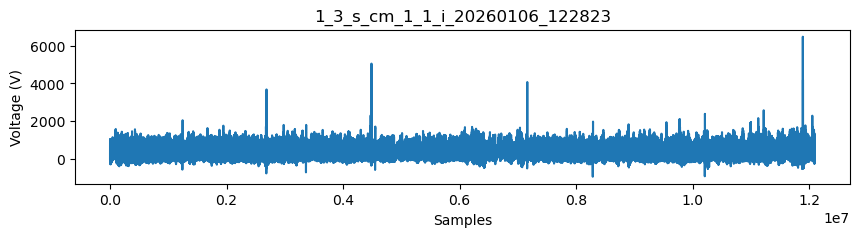

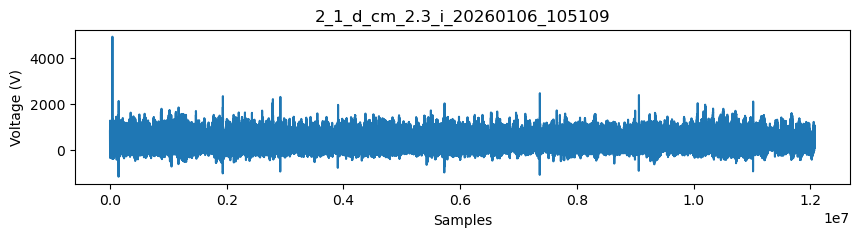

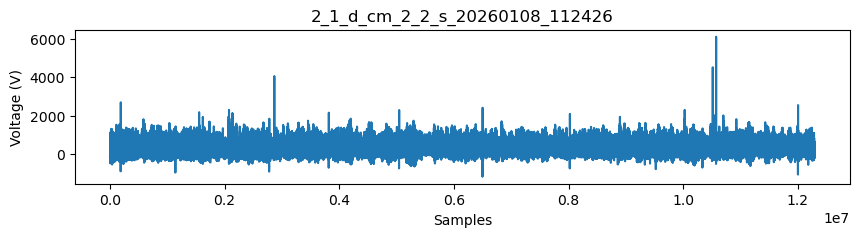

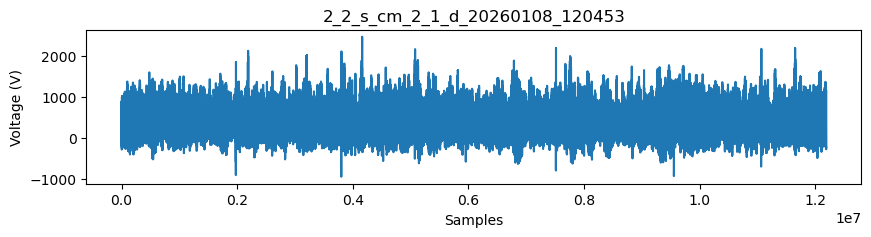

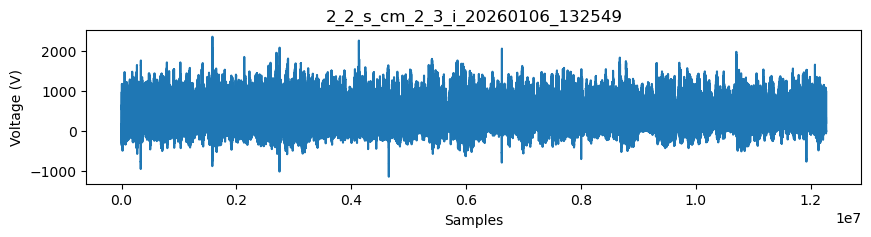

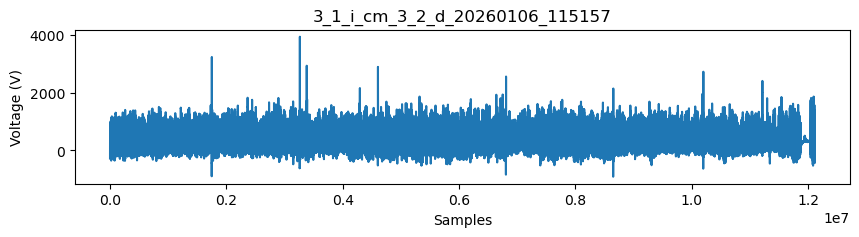

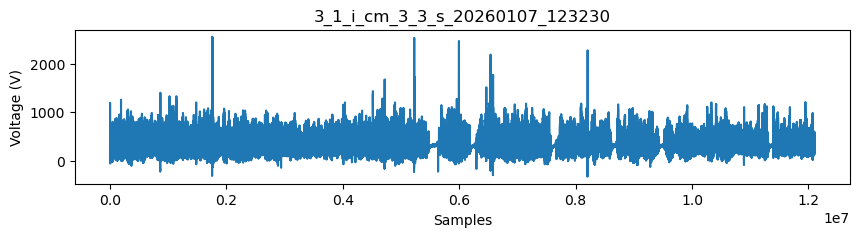

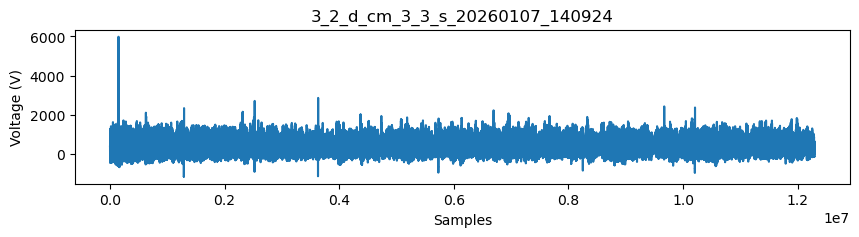

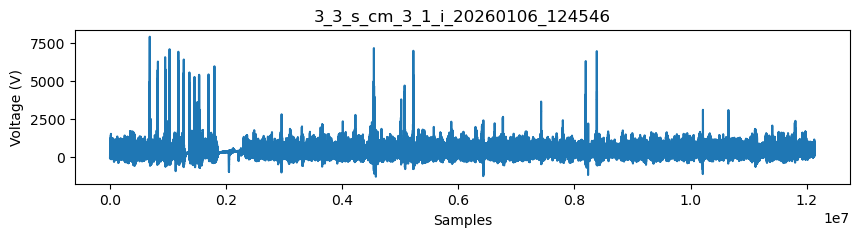

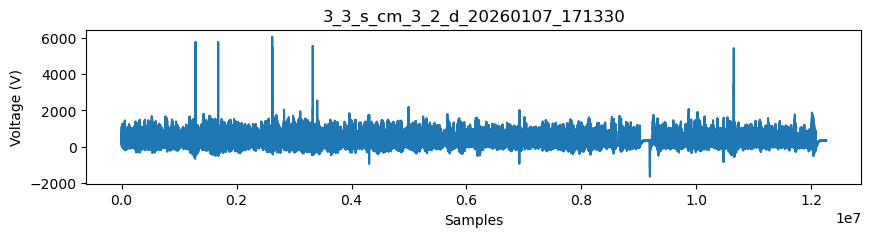

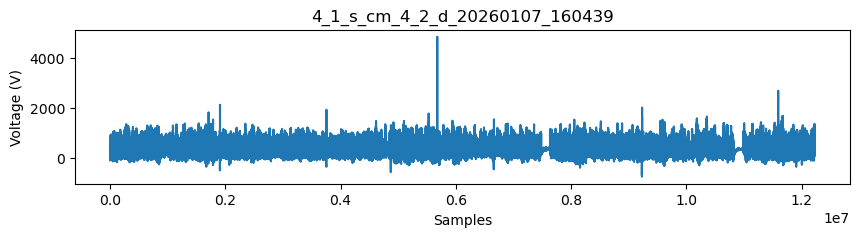

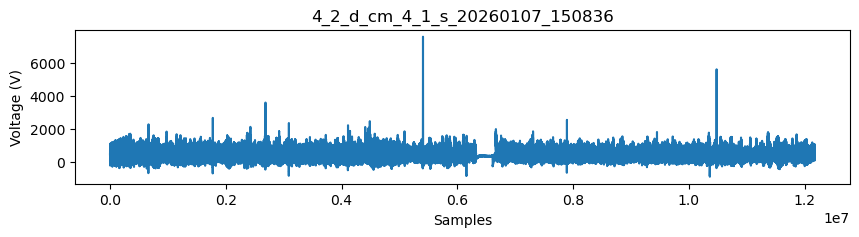

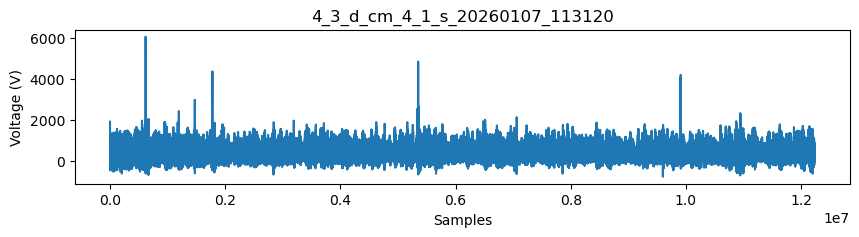

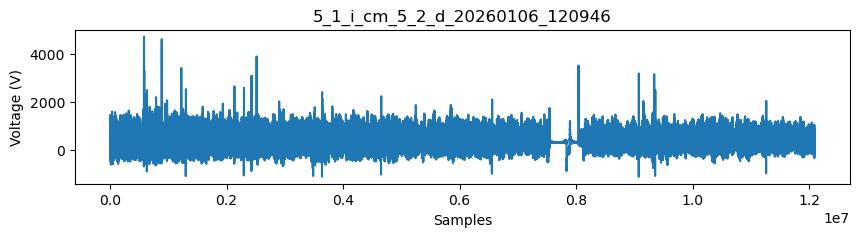

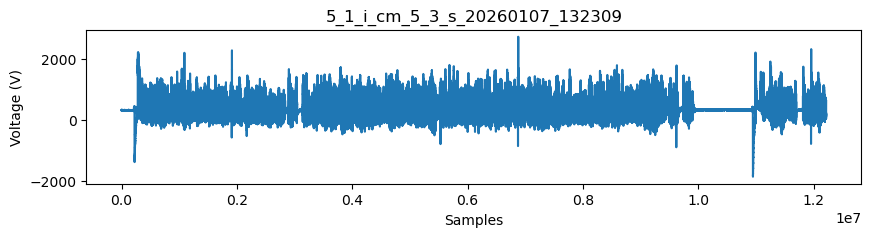

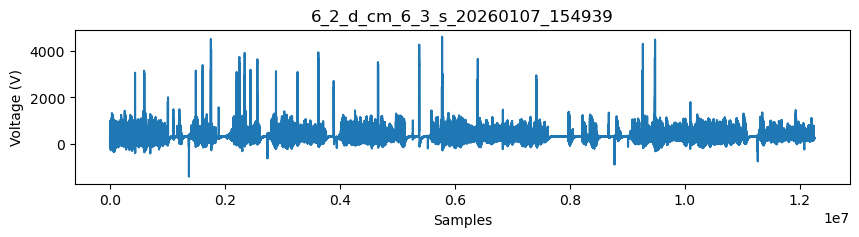

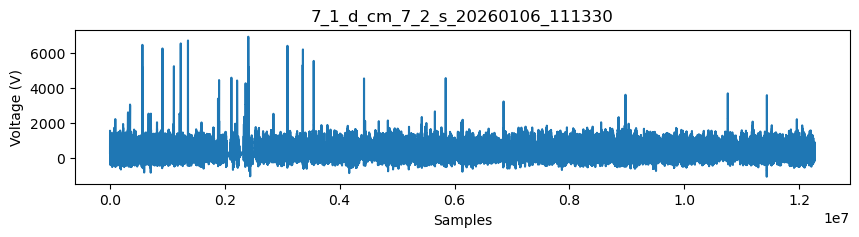

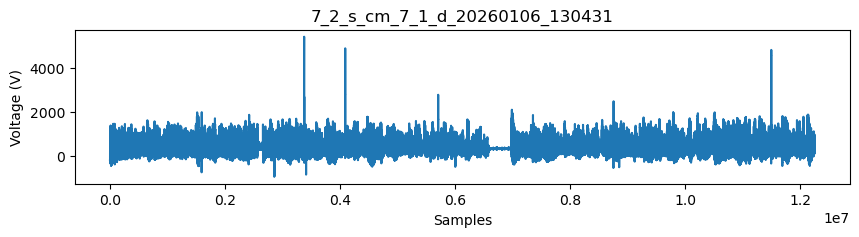

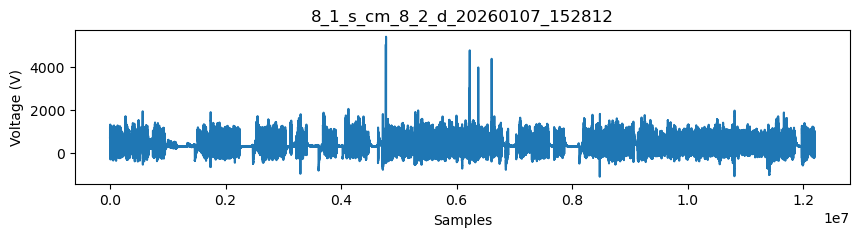

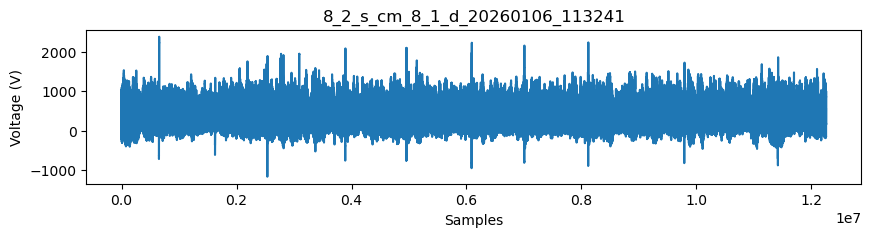

In [51]:
import matplotlib.pyplot as plt

for sess, data in all_sessions.items():
    analog = data["analog"]
    key = [k for k in analog if "Ain1" in k][0]
    resp = analog[key]["voltage"]

    plt.figure(figsize=(10, 2))
    plt.plot(resp)
    plt.title(sess)
    plt.ylabel("Voltage (V)")
    plt.xlabel("Samples")
    plt.show()